<a href="https://colab.research.google.com/github/theajelwan/LebanonPulse/blob/main/LebanonPulse_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LebanonPulse
## Detecting Negative Sentiment in Lebanese Arabic Reviews

LebanonPulse is a machine learning project that explores sentiment analysis for Lebanese Arabic customer reviews. The project focuses on the challenge of class imbalance and investigates whether balancing the training process can improve detection of negative feedback.

## 1. Dataset Loading and Exploration


In [3]:
import pandas as pd

# Download OCLAR directly from UCI
!wget -q "https://archive.ics.uci.edu/static/public/499/opinion%2Bcorpus%2Bfor%2Blebanese%2Barabic%2Breviews%2Boclar.zip" -O oclar.zip

# Unzip the dataset
!unzip -o -q oclar.zip

# Load the CSV
df = pd.read_csv("OCLAR - Opinion Corpus for Lebanese Arabic Reviews.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (3916, 3)

Columns:
['pagename', 'review', 'rating']

First 5 rows:


,pagename,review,rating
0,Beirut Golden Plaza Suites,هذا الفندق ينقصه بعض الاشياء داخل الغرف مثلا ع...,2
1,Beirut Golden Plaza Suites,لطيف ولكن الغرف الفندقية تحتاج صيانة كادر الخد...,4
2,Beirut Golden Plaza Suites,مكان جميل جدا وحسن الخلق والضيافه,5
3,Beirut Golden Plaza Suites,بحاجة الى اعادة تأهيل للمفروشات,3
4,Beirut Golden Plaza Suites,فندق ممتاز ومعاملة راقية جدا,5


In [4]:
print("Rating distribution:")
print(df["rating"].value_counts().sort_index())

Rating distribution:
rating
1     303
2     148
3     418
4     734
5    2313
Name: count, dtype: int64


## 2. Sentiment Labeling

Reviews rated 1–2 stars are labeled Negative, while reviews rated 4–5 stars are labeled Positive. Three-star reviews are excluded because their sentiment is more ambiguous.


In [5]:
# Keep only clearly positive and clearly negative reviews
df_model = df[df["rating"] != 3].copy()

# 1-2 stars = Negative, 4-5 stars = Positive
df_model["sentiment"] = df_model["rating"].apply(
    lambda x: "Negative" if x <= 2 else "Positive"
)

print("Reviews used:", len(df_model))
print("\nSentiment distribution:")
print(df_model["sentiment"].value_counts())

display(df_model[["review", "rating", "sentiment"]].head(10))

Reviews used: 3498

Sentiment distribution:
sentiment
Positive    3047
Negative     451
Name: count, dtype: int64


,review,rating,sentiment
0,هذا الفندق ينقصه بعض الاشياء داخل الغرف مثلا ع...,2,Negative
1,لطيف ولكن الغرف الفندقية تحتاج صيانة كادر الخد...,4,Positive
2,مكان جميل جدا وحسن الخلق والضيافه,5,Positive
4,فندق ممتاز ومعاملة راقية جدا,5,Positive
5,فندق ممتاز ومعاملة راقية جدا,4,Positive
6,رائع وجميل,5,Positive
7,ممتع ..مسلي .. مريح,5,Positive
8,انه جميل وراقي 😙😙😙😍😍❤❤,5,Positive
10,مكان بعيد عن مركز المدينه . الخدمه ممتازة الوا...,4,Positive
11,هو فندق كبير، وذو غرف كبيرة واسعة، وقريب جدا م...,4,Positive


## 3. Train-Test Split


In [6]:
from sklearn.model_selection import train_test_split

X = df_model["review"].astype(str)
y = df_model["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training reviews: 2798
Testing reviews: 700

Training label distribution:
sentiment
Positive    2437
Negative     361
Name: count, dtype: int64

Testing label distribution:
sentiment
Positive    610
Negative     90
Name: count, dtype: int64


## 4. Baseline Model

The baseline uses TF-IDF to represent review text numerically and Logistic Regression for sentiment classification.


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Baseline model: TF-IDF + Logistic Regression
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


## 5. Addressing Class Imbalance

Because negative reviews are much less common than positive reviews, a second Logistic Regression model is trained using balanced class weights.



Baseline Accuracy: 0.8957

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.19      0.32        90
    Positive       0.89      1.00      0.94       610

    accuracy                           0.90       700
   macro avg       0.95      0.59      0.63       700
weighted avg       0.91      0.90      0.86       700



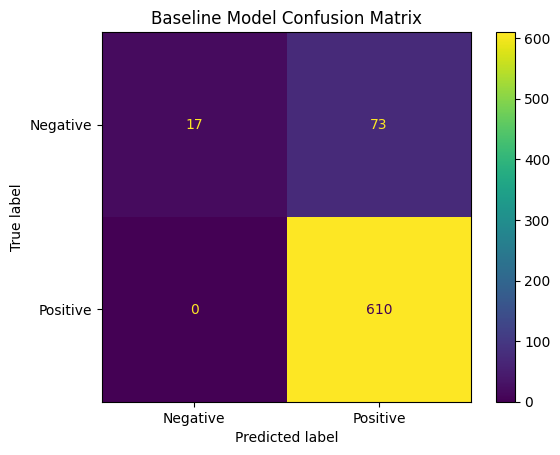

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)

# Accuracy
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    labels=["Negative", "Positive"]
)

plt.title("Baseline Model Confusion Matrix")
plt.show()

In [9]:
# Balanced model: gives more importance to the minority negative class
balanced_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

print("Balanced model trained successfully!")

Balanced model trained successfully!


Balanced Model Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.66      0.58        90
    Positive       0.95      0.91      0.93       610

    accuracy                           0.88       700
   macro avg       0.74      0.78      0.76       700
weighted avg       0.89      0.88      0.89       700



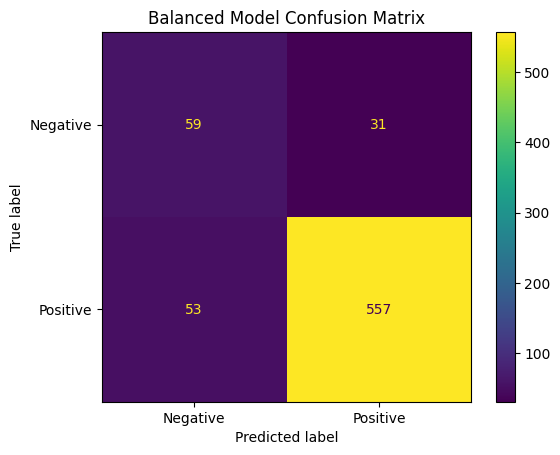

In [10]:
# Evaluate the balanced model
y_pred_balanced = balanced_model.predict(X_test)

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Balanced Model Accuracy:", round(balanced_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    labels=["Negative", "Positive"]
)

plt.title("Balanced Model Confusion Matrix")
plt.show()

## 6. Model Comparison


In [11]:
from sklearn.metrics import precision_recall_fscore_support

# Get metrics for the Negative class
base_precision, base_recall, base_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_baseline, labels=["Negative"], average=None
)

bal_precision, bal_recall, bal_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_balanced, labels=["Negative"], average=None
)

comparison = pd.DataFrame({
    "Model": ["Baseline", "Balanced"],
    "Accuracy": [baseline_accuracy, balanced_accuracy],
    "Negative Precision": [base_precision[0], bal_precision[0]],
    "Negative Recall": [base_recall[0], bal_recall[0]],
    "Negative F1": [base_f1[0], bal_f1[0]]
})

comparison = comparison.round(3)

display(comparison)

,Model,Accuracy,Negative Precision,Negative Recall,Negative F1
0,Baseline,0.896,1.000,0.189,0.318
1,Balanced,0.880,0.527,0.656,0.584


## 7. LebanonPulse Demo


In [13]:
def predict_sentiment(review_text):
    prediction = balanced_model.predict([review_text])[0]
    probabilities = balanced_model.predict_proba([review_text])[0]

    classes = balanced_model.classes_
    confidence = probabilities[list(classes).index(prediction)]

    print("Review:", review_text)
    print("Predicted sentiment:", prediction)
    print("Confidence:", f"{confidence:.1%}")

# Try a Lebanese Arabic review
predict_sentiment("المحل كتير حلو والخدمة ممتازة")

Review: المحل كتير حلو والخدمة ممتازة
Predicted sentiment: Positive
Confidence: 84.2%


## 8. Key Finding

The baseline model achieved higher overall accuracy, but detected only 18.9% of negative reviews. After applying class balancing, negative recall increased to 65.6% and negative F1-score increased from 0.318 to 0.584, while overall accuracy decreased only slightly from 89.6% to 88.0%.

This demonstrates why accuracy alone can be misleading when working with imbalanced datasets. For LebanonPulse, the balanced model is more useful because identifying negative feedback is an important goal of the system.
